# Phase 2 Visualization — 코호트·LTV·재구매 간격

6개 차트를 BigQuery 분석 결과로부터 산출해 `visualizations/`에 PNG로 저장한다.

1. 코호트 리텐션 히트맵 (`cohort_retention_heatmap.png`)
2. 세그먼트별 LTV 막대그래프 (`segment_ltv.png`)
3. ARPU 역설 산점도 (`arpu_paradox.png`)
4. IPT 산출 가능 비율 (`ipt_eligibility.png`)
5. IPT 분포 박스플롯 (`ipt_distribution.png`)
6. Phase 2 핵심 발견 요약 카드 (`phase2_summary.png`)

## 0. 환경 세팅

In [1]:
from pathlib import Path
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
import seaborn as sns

PROJECT_ID = 'ecomm-extension'
RAW      = f'`{PROJECT_ID}.ecomm_raw`'
ANALYSIS = f'`{PROJECT_ID}.ecomm_analysis`'
client = bigquery.Client(project=PROJECT_ID)

# 한글 폰트 (Phase 1 노트북과 동일 패턴)
korean_font = None
for path in ['C:/Windows/Fonts/NanumGothic.ttf',
             'C:/Windows/Fonts/malgun.ttf']:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        korean_font = fm.FontProperties(fname=path).get_name()
        break
sns.set_style('whitegrid')
plt.rcParams['font.family'] = korean_font or 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
print(f'한글 폰트: {korean_font}')

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'sql').exists() else Path.cwd().parent
VIZ_DIR = PROJECT_ROOT / 'visualizations'
VIZ_DIR.mkdir(exist_ok=True)

def q(sql):
    return client.query(sql).to_dataframe()

def savefig(name):
    out = VIZ_DIR / name
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'saved: {out}')

# 세그먼트 색상 팔레트 (전 차트 공통)
SEG_COLORS = {
    '핵심 파트너 고객': '#E07B5B',
    '성장형 고객':      '#4A90D9',
    '유망 고객':        '#88B04B',
    '이탈 위험 고객':   '#F1C40F',
    '장기 비활성 고객': '#7F8C8D',
    '기타':              '#BDC3C7',
}

한글 폰트: NanumGothic


## 1. 코호트 리텐션 히트맵

가입월 × 월차 매트릭스. NULL 셀(관측 기간 부족)은 회색. 1월 코호트 m5~m7 반등 구간 강조.

In [ ]:
cohort = q(f'SELECT * FROM {ANALYSIS}.cohort_retention ORDER BY `가입월`')
cohort_size = cohort.set_index('가입월')['가입자수']
heatmap_data = cohort.set_index('가입월').drop(columns='가입자수')

fig, (ax_main, ax_size) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={'width_ratios': [10, 1.2], 'wspace': 0.05}
)

data = heatmap_data.values.astype(float)
mask = np.isnan(data)
yticks = [pd.to_datetime(d).strftime('%Y-%m') for d in heatmap_data.index]

sns.heatmap(
    data, mask=mask, annot=True, fmt='.1f',
    cmap='RdYlGn', xticklabels=heatmap_data.columns,
    yticklabels=yticks,
    cbar_kws={'label': '리텐션 (%)'},
    ax=ax_main, vmin=0, vmax=30, linewidths=0.4, linecolor='white'
)
ax_main.set_facecolor('#E0E0E0')

# 1월 코호트 m5~m7 강조 박스 (시각적 앵커 유지). 텍스트 라벨은 자막으로 이동.
ax_main.add_patch(Rectangle((5, 0), 3, 1, fill=False,
                             edgecolor='navy', lw=2.5))

ax_main.set_xlabel('월차')
ax_main.set_ylabel('가입월')
ax_main.set_title('코호트 리텐션 매트릭스 (%)', fontsize=12, pad=10)

# 우측 가입자수 바
y_pos = np.arange(len(cohort_size))
ax_size.barh(y_pos, cohort_size.values, color='#999', height=0.7)
ax_size.set_yticks(y_pos)
ax_size.set_yticklabels([])
ax_size.invert_yaxis()
ax_size.set_xlabel('가입자수', fontsize=9)
for i, v in enumerate(cohort_size.values):
    ax_size.text(v + max(cohort_size)*0.02, i, str(int(v)),
                 va='center', fontsize=8)
ax_size.set_xlim(0, max(cohort_size) * 1.3)
ax_size.grid(False)
ax_size.spines[['top', 'right']].set_visible(False)

fig.suptitle('1개월차 평균 리텐션 9.68% — 가입 직후 90% 이탈\n'
             '1월 코호트는 m5~m7에서 20%대로 반등 (네이비 강조)',
             fontsize=11, y=0.03, color='#444')
plt.tight_layout()
savefig('cohort_retention_heatmap.png')
plt.show()

## 2. 세그먼트별 LTV — 2 패널 + 부 그래프

saved: d:\프로젝트\e_commerce\visualizations\segment_ltv.png


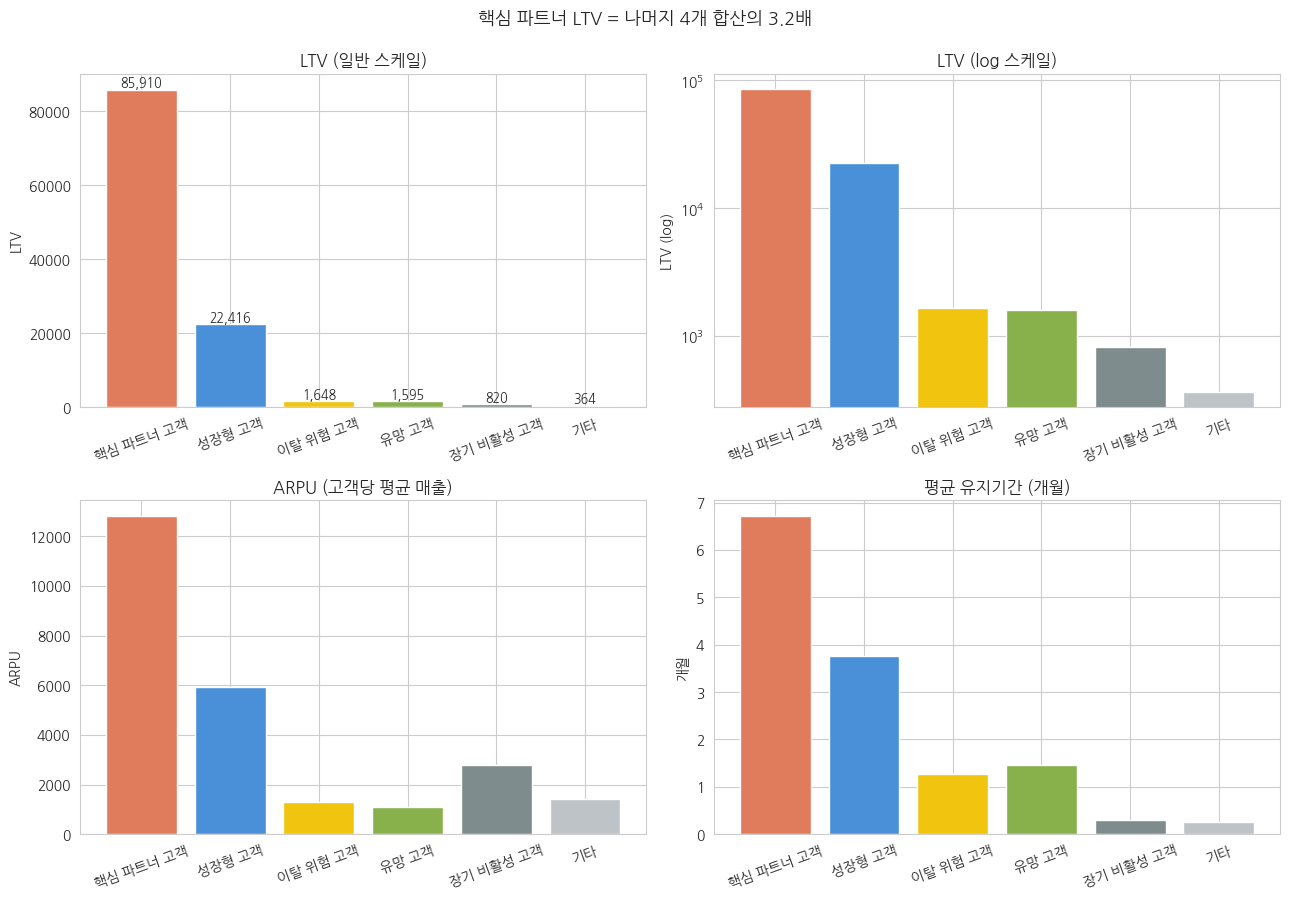

In [3]:
seg = q(f'SELECT * FROM {ANALYSIS}.segment_ltv_summary')
seg_only = seg[seg['세그먼트'] != 'ALL'].sort_values('LTV', ascending=False).reset_index(drop=True)

colors_list = [SEG_COLORS.get(s, '#666') for s in seg_only['세그먼트']]
core_ltv = seg_only.loc[seg_only['세그먼트']=='핵심 파트너 고객', 'LTV'].iloc[0]
rest_ltv = seg_only.loc[seg_only['세그먼트']!='핵심 파트너 고객', 'LTV'].sum()
ratio = core_ltv / rest_ltv if rest_ltv else float('nan')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) LTV 일반
ax = axes[0, 0]
bars = ax.bar(seg_only['세그먼트'], seg_only['LTV'], color=colors_list)
ax.set_title('LTV (일반 스케일)')
ax.set_ylabel('LTV')
for b, v in zip(bars, seg_only['LTV']):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,.0f}',
            ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=20)

# (2) LTV log
ax = axes[0, 1]
ax.bar(seg_only['세그먼트'], seg_only['LTV'], color=colors_list)
ax.set_yscale('log')
ax.set_title('LTV (log 스케일)')
ax.set_ylabel('LTV (log)')
ax.tick_params(axis='x', rotation=20)

# (3) ARPU
ax = axes[1, 0]
ax.bar(seg_only['세그먼트'], seg_only['ARPU'], color=colors_list)
ax.set_title('ARPU (고객당 평균 매출)')
ax.set_ylabel('ARPU')
ax.tick_params(axis='x', rotation=20)

# (4) 평균 유지기간
ax = axes[1, 1]
ax.bar(seg_only['세그먼트'], seg_only['평균유지기간_월'], color=colors_list)
ax.set_title('평균 유지기간 (개월)')
ax.set_ylabel('개월')
ax.tick_params(axis='x', rotation=20)

fig.suptitle(f'핵심 파트너 LTV = 나머지 4개 합산의 {ratio:.1f}배',
             fontsize=13, y=0.995)
plt.tight_layout()
savefig('segment_ltv.png')
plt.show()

## 3. ARPU 역설 산점도

x = 평균 유지기간, y = ARPU, 점 크기 = 고객수. 장기 비활성이 좌상단(짧은 유지 + 높은 ARPU)에 위치하면 거액 단발 이탈자.

saved: d:\프로젝트\e_commerce\visualizations\arpu_paradox.png


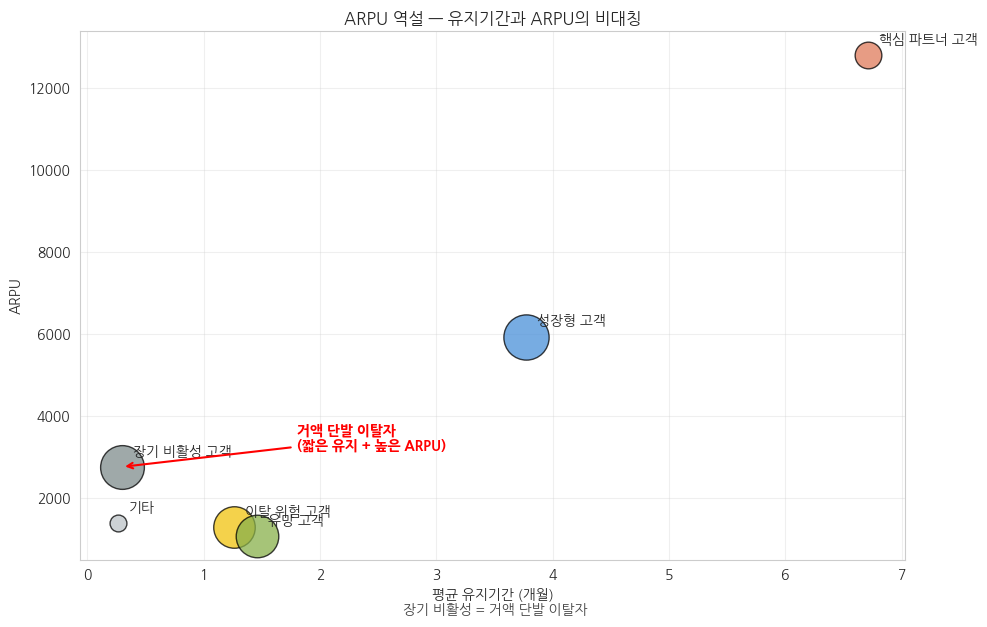

In [4]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for _, row in seg_only.iterrows():
    seg_name = row['세그먼트']
    ax.scatter(
        row['평균유지기간_월'], row['ARPU'],
        s=row['고객수'] * 3,
        c=SEG_COLORS.get(seg_name, '#666'),
        alpha=0.75, edgecolor='black', linewidth=1
    )
    ax.annotate(seg_name, (row['평균유지기간_월'], row['ARPU']),
                fontsize=10, xytext=(8, 8), textcoords='offset points')

inactive = seg_only[seg_only['세그먼트']=='장기 비활성 고객']
if len(inactive):
    inactive = inactive.iloc[0]
    ax.annotate(
        '거액 단발 이탈자\n(짧은 유지 + 높은 ARPU)',
        xy=(inactive['평균유지기간_월'], inactive['ARPU']),
        xytext=(inactive['평균유지기간_월']+1.5, inactive['ARPU']*1.15),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        fontsize=10, color='red', fontweight='bold'
    )

ax.set_xlabel('평균 유지기간 (개월)')
ax.set_ylabel('ARPU')
ax.set_title('ARPU 역설 — 유지기간과 ARPU의 비대칭')
ax.grid(True, alpha=0.3)
fig.suptitle('장기 비활성 = 거액 단발 이탈자',
             fontsize=10, y=0.02, color='#444')
plt.tight_layout()
savefig('arpu_paradox.png')
plt.show()

## 4. IPT 산출 가능 비율 (세그먼트별 stacked bar)

산출 가능 = 2일 이상 거래 (재구매 있음). 산출 불가 = 같은 날(들)에만 거래. RFM 분위에 기반한 세그먼트 안에서도 행동 차이가 드러난다.

saved: d:\프로젝트\e_commerce\visualizations\ipt_eligibility.png


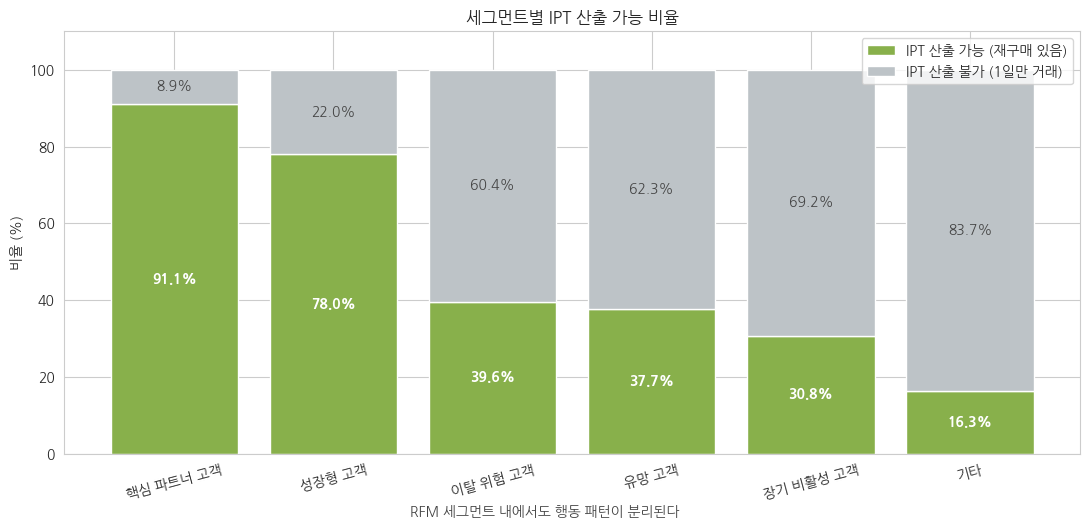

In [5]:
ipt_elig = q(f'''
WITH days_per_customer AS (
  SELECT `고객ID`, COUNT(DISTINCT `거래날짜`) AS `거래일수`
  FROM {RAW}.Onlinesales
  GROUP BY `고객ID`
)
SELECT
  cm.Customer_Segment AS `세그먼트`,
  COUNTIF(dpc.`거래일수` >= 2) AS `IPT_가능`,
  COUNTIF(dpc.`거래일수`  < 2) AS `IPT_불가`
FROM {ANALYSIS}.customer_master AS cm
JOIN days_per_customer AS dpc USING(`고객ID`)
GROUP BY cm.Customer_Segment
''')
ipt_elig['전체']    = ipt_elig['IPT_가능'] + ipt_elig['IPT_불가']
ipt_elig['가능_pct'] = (ipt_elig['IPT_가능'] / ipt_elig['전체'] * 100).round(1)
ipt_elig['불가_pct'] = (ipt_elig['IPT_불가'] / ipt_elig['전체'] * 100).round(1)
ipt_elig = ipt_elig.sort_values('가능_pct', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(ipt_elig))
ax.bar(x, ipt_elig['가능_pct'], label='IPT 산출 가능 (재구매 있음)', color='#88B04B')
ax.bar(x, ipt_elig['불가_pct'], bottom=ipt_elig['가능_pct'],
       label='IPT 산출 불가 (1일만 거래)', color='#BDC3C7')

for i, row in ipt_elig.iterrows():
    ax.text(i, row['가능_pct']/2, f"{row['가능_pct']:.1f}%",
            ha='center', va='center', color='white', fontweight='bold')
    if row['불가_pct'] > 3:
        ax.text(i, row['가능_pct']+row['불가_pct']/2, f"{row['불가_pct']:.1f}%",
                ha='center', va='center', color='#444')

ax.set_xticks(x)
ax.set_xticklabels(ipt_elig['세그먼트'], rotation=15)
ax.set_ylabel('비율 (%)')
ax.set_ylim(0, 110)
ax.set_title('세그먼트별 IPT 산출 가능 비율')
ax.legend(loc='upper right')
fig.suptitle('RFM 세그먼트 내에서도 행동 패턴이 분리된다',
             fontsize=10, y=0.02, color='#444')
plt.tight_layout()
savefig('ipt_eligibility.png')
plt.show()

## 5. IPT 분포 박스플롯

세그먼트별 재구매 간격(일자 단위) 분포. 각 박스 위에 표본 수 n, 장기 비활성의 p50 ≈ 1일을 강조.

C:\Users\yun72_92xubzr\AppData\Local\Temp\ipykernel_23180\2568629186.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=order, showfliers=False,


saved: d:\프로젝트\e_commerce\visualizations\ipt_distribution.png


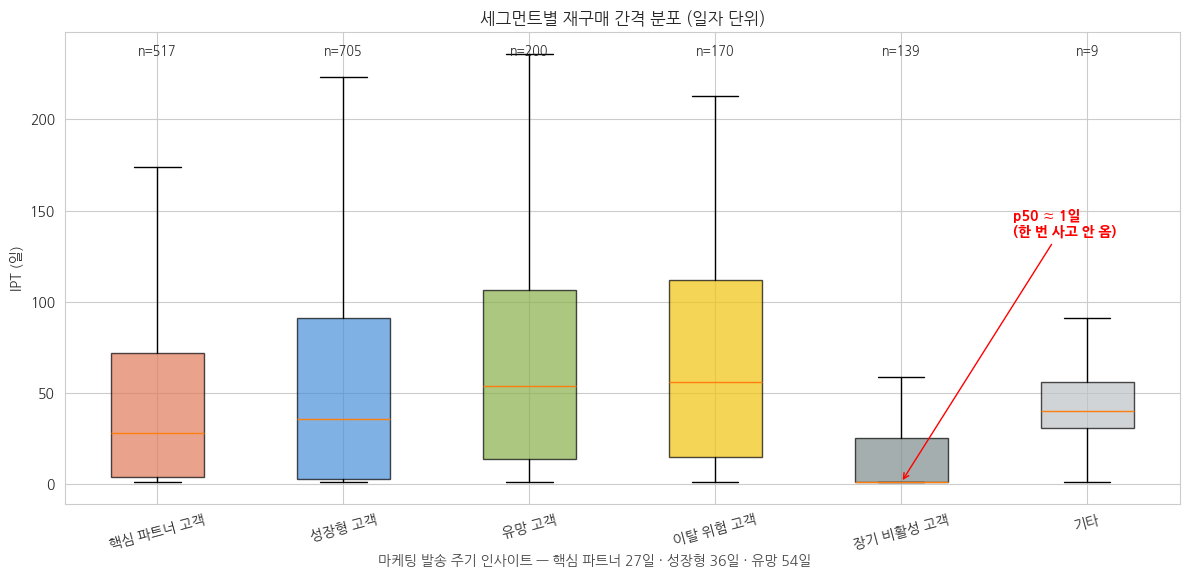

In [6]:
ipt_raw = q(f'''
SELECT
  cm.Customer_Segment AS `세그먼트`,
  DATE_DIFF(
    td.`거래날짜`,
    LAG(td.`거래날짜`) OVER (PARTITION BY td.`고객ID` ORDER BY td.`거래날짜`),
    DAY
  ) AS IPT
FROM (SELECT DISTINCT `고객ID`, `거래날짜` FROM {RAW}.Onlinesales) AS td
JOIN {ANALYSIS}.customer_master AS cm USING(`고객ID`)
''')
ipt_raw = ipt_raw[ipt_raw['IPT'].notna()]

order = ['핵심 파트너 고객', '성장형 고객', '유망 고객',
         '이탈 위험 고객', '장기 비활성 고객', '기타']
order = [s for s in order if s in ipt_raw['세그먼트'].unique()]

fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = [ipt_raw[ipt_raw['세그먼트']==s]['IPT'].values for s in order]
bp = ax.boxplot(data_to_plot, labels=order, showfliers=False,
                patch_artist=True)
for patch, s in zip(bp['boxes'], order):
    patch.set_facecolor(SEG_COLORS.get(s, '#666'))
    patch.set_alpha(0.7)

y_top = ax.get_ylim()[1]
for i, s in enumerate(order):
    n = len(ipt_raw[ipt_raw['세그먼트']==s])
    ax.text(i+1, y_top*0.95, f'n={n:,}', ha='center', fontsize=9)

if '장기 비활성 고객' in order:
    idx = order.index('장기 비활성 고객') + 1
    ax.annotate(
        'p50 ≈ 1일\n(한 번 사고 안 옴)',
        xy=(idx, 1), xytext=(idx + 0.6, y_top*0.55),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=10, color='red', fontweight='bold'
    )

ax.set_ylabel('IPT (일)')
ax.set_title('세그먼트별 재구매 간격 분포 (일자 단위)')
plt.xticks(rotation=15)
fig.suptitle('마케팅 발송 주기 인사이트 — 핵심 파트너 27일 · 성장형 36일 · 유망 54일',
             fontsize=10, y=0.02, color='#444')
plt.tight_layout()
savefig('ipt_distribution.png')
plt.show()

## 6. Phase 2 핵심 발견 요약 카드

8개 발견을 한 장으로. 자소서·README 첨부용 infographic.

In [ ]:
findings = [
    ('가입 직후 90% 이탈',     '1개월차 리텐션 9.68%',           '코호트 매트릭스로 최대 이탈 시점 식별'),
    ('1월 코호트 중기 반등',   'm5~m7 20%대 회복',               '단조 감소 가정이 깨지는 사례'),
    ('3월·6월 코호트 강세',    'm2 각 19.8% · 16.1%',            '시즈널 코호트 효과 확인'),
    ('핵심 파트너 LTV 압도',   '나머지 4개 합산의 3배',           'RFM 분류의 실제 가치 집중'),
    ('ARPU 역설',              '장기 비활성 = 거액 단발 이탈자',  '같은 ARPU도 유지기간 따라 가치 다름'),
    ('세그먼트 내 행동 분리',  'IPT 산출 가능 비율 차',           'RFM 외 행동 차원의 추가 신호'),
    ('발송 주기 차별',         '핵심 27일 · 성장 36일 · 유망 54일', '세그먼트별 캠페인 주기 데이터 기반'),
    ('장기 비활성 p50 ≈ 1일',  '한 번 사고 안 옴',                '재활성보다 신규 획득이 우선'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, num, msg) in zip(axes.flat, findings):
    ax.axis('off')
    ax.add_patch(Rectangle(
        (0.04, 0.06), 0.92, 0.88, fill=True,
        facecolor='#F8F9FA', edgecolor='#CCCCCC', lw=1.5,
        transform=ax.transAxes
    ))
    ax.text(0.5, 0.78, title, ha='center', va='center',
            fontsize=13, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.50, num, ha='center', va='center',
            fontsize=12, color='#E07B5B', fontweight='bold',
            transform=ax.transAxes)
    ax.text(0.5, 0.22, msg, ha='center', va='center',
            fontsize=10, color='#555',
            transform=ax.transAxes)

fig.suptitle('Phase 2 — 코호트 · LTV · 재구매 간격 핵심 발견',
             fontsize=16, y=0.99, fontweight='bold')
plt.tight_layout()
savefig('phase2_summary.png')
plt.show()

## 마무리

6개 PNG가 `visualizations/`에 저장되었다. `reports/phase2_findings.md`에 8개 발견을 자소서 스타일로 정리하고, 루트 `README.md`의 "주요 결과" 섹션을 업데이트하는 것으로 Phase 2를 마감한다. 다음은 Phase 3 — 쿠폰 효과의 PSM 인과추론.